## ***Sales Forecasting System***

In [34]:
# Step 1: Data Collection & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [35]:
# Load dataset (Replace 'train.csv' with your actual file path)
df = pd.read_csv('train.csv')

print("Initial Data Shape:", df.shape)
display(df.head())

Initial Data Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [36]:
# Step 2: Data Cleaning
# Handle missing values and drop duplicates
df.dropna(subset=['Order Date', 'Sales'], inplace=True)
df.drop_duplicates(inplace=True)

In [37]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [38]:
# Convert date column properly to datetime format
#df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [39]:
# Sort by date for chronological consistency
df = df.sort_values('Order Date').reset_index(drop=True)

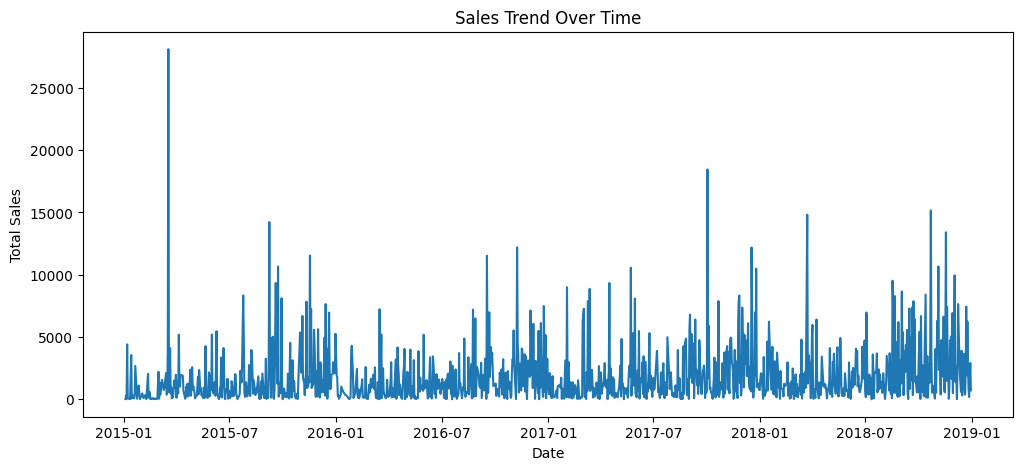

In [40]:
# Step 3: Exploratory Data Analysis (EDA) & Visualization
plt.figure(figsize=(12, 5))
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
sns.lineplot(data=daily_sales, x='Order Date', y='Sales')
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [41]:
# Step 4: Feature Engineering
# Extract time-based features from the date column
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

# Select features and target variable for modeling
features = ['Year', 'Month', 'Day', 'DayOfWeek']
X = df[features]
y = df['Sales']

In [42]:
# Step 5: Model Building & Training/Testing Split
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [43]:
# Step 6: Prediction
# Predict future sales on the test dataset
y_pred = model.predict(X_test)

# Compare actual vs predicted values using a small DataFrame preview
comparison_df = pd.DataFrame({'Actual Sales': y_test.values, 'Predicted Sales': y_pred})
print(comparison_df.head(10))

   Actual Sales  Predicted Sales
0        43.000       145.374241
1       735.980       145.374241
2       101.940       212.181178
3        14.940       212.181178
4         2.864       212.181178
5         3.520       212.181178
6       222.320       212.181178
7         6.480       212.181178
8        16.340       212.181178
9       225.296       212.181178


In [44]:
# Step 7: Evaluation
# Check model performance using MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 295.4814
Root Mean Square Error (RMSE): 625.5903
